# Librerias

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import re
import causalidad as cs

Initializing causalidad package...
causalidad package initialized successfully.


# Lectura de datos

In [ ]:
df_icare = pd.read_csv(r"C:\Users\afpue\OneDrive\Documentos\GitHub\causalidad\Codigo\df_icare_260226.csv")

# Funciones

## Calcular el ATE

In [ ]:
cols = ['actfreq_sq001', 'recgov_sq001']

df_icare[cols] = df_icare[cols].apply(lambda x: (x == 1).astype(int))
resultado = cs.calcular_ate(
    df=df_icare,
    resultado='actfreq_sq001',
    tratamiento='recgov_sq001',
    covariables=['sex', 'age', 'edu']
)

if resultado is not None:
    print(f"ATE (diferencia de medias): {resultado['ate_diff']:.4f}")
    print(f"ATE (regresión ajustada):   {resultado['ate_reg']:.4f} (p-valor: {resultado['p_valor_reg']:.4f})")
    print(f"N tratados: {resultado['n_tratados']}, N controles: {resultado['n_controles']}")

ATE (diferencia de medias): 0.4244
ATE (regresión ajustada):   0.4120 (p-valor: 0.0000)
N tratados: 1645, N controles: 18


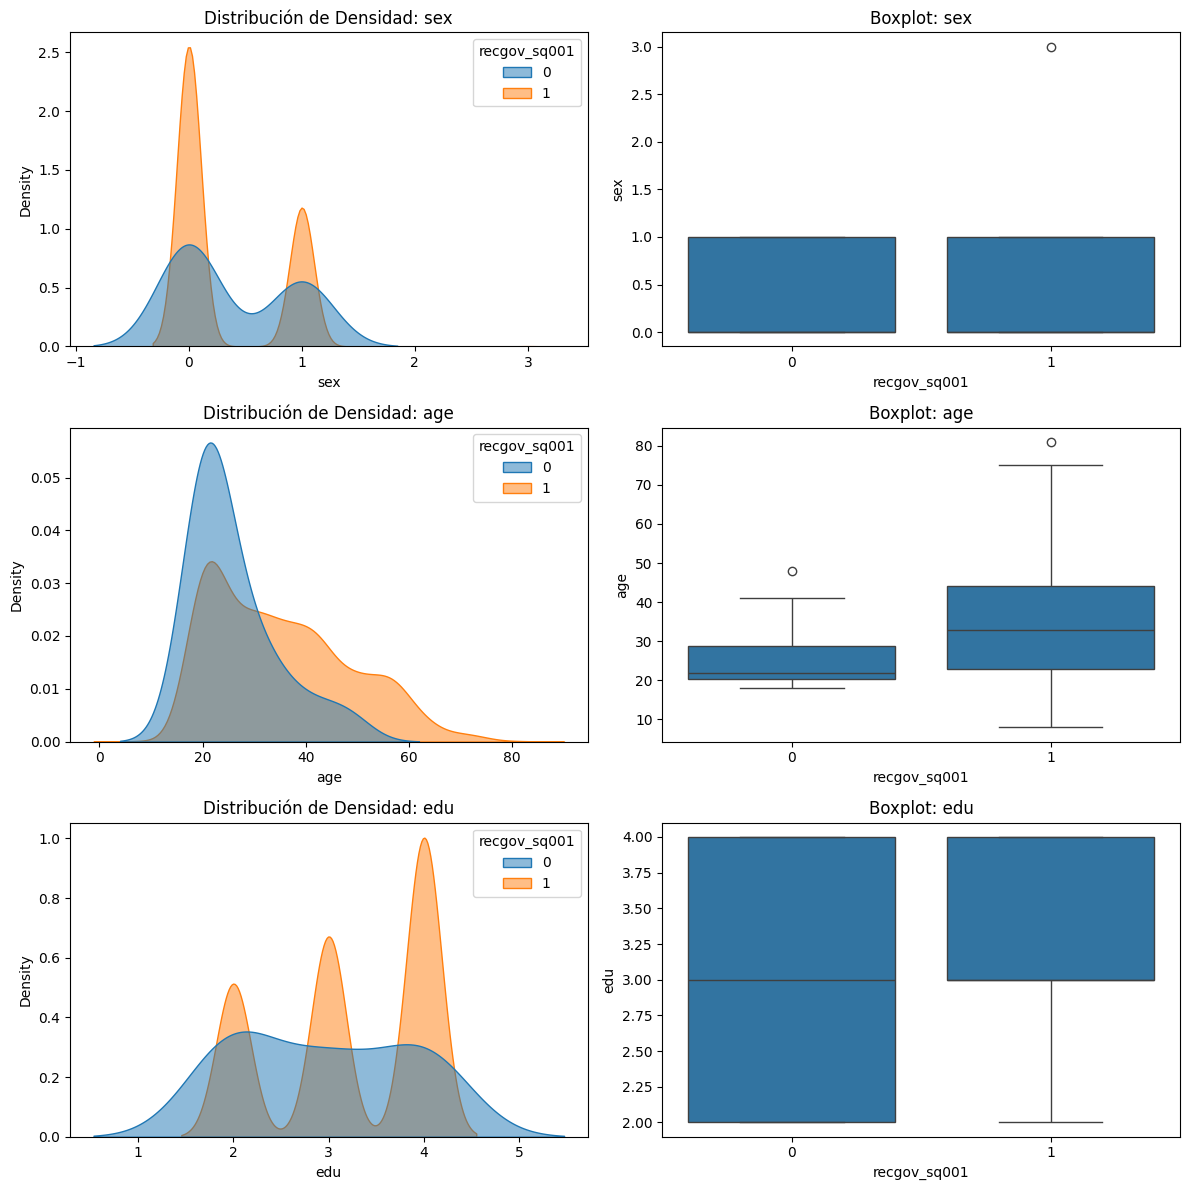

,Covariable,Tratados (Media ± SD),Controles (Media ± SD),p-valor (Prueba de Medias),SMD,Balanceado
0,sex,0.32 ± 0.47,0.39 ± 0.50,0.5581,0.1460,Sí
1,age,35.21 ± 13.39,25.83 ± 8.31,0.0002,0.8410,No
2,edu,3.22 ± 0.80,2.94 ± 0.87,0.1939,0.3332,Sí


In [ ]:
cs.visualizar_balance(
    df=df_icare,
    tratamiento='recgov_sq001',
    covariables=['sex', 'age', 'edu']
)

In [ ]:
import re
import pandas as pd

# 1. Identificar sufijos de las columnas disponibles
sufijos = sorted([re.search(r'sq(\d+)', col).group(1) 
                  for col in df_icare.columns if col.startswith('actfreq_sq')])

lista_resultados = []

# 2. Iterar y recolectar datos
for num in sufijos:
    col_resultado = f'actfreq_sq{num}'
    col_tratamiento = f'recgov_sq{num}'
    
    if col_tratamiento in df_icare.columns:
        # Limpieza rápida para asegurar formato 0/1
        df_temp = df_icare[[col_resultado, col_tratamiento, 'sex', 'age', 'edu']].copy().dropna()
        df_temp[col_resultado] = (df_temp[col_resultado] == 1).astype(int)
        df_temp[col_tratamiento] = (df_temp[col_tratamiento] == 1).astype(int)
        
        # Llamada a tu función de ATE
        res = cs.calcular_ate(
            df=df_temp,
            resultado=col_resultado,
            tratamiento=col_tratamiento,
            covariables=['sex', 'age', 'edu']
        )
        
        # Guardar en la lista si se pudo calcular
        if res is not None:
            lista_resultados.append({
                'ID': num,
                'Variable Resultado': col_resultado,
                'Tratamiento': col_tratamiento,
                'ATE (Diff)': round(res['ate_diff'], 4),
                'ATE (Reg)': round(res['ate_reg'], 4),
                'p-valor (Reg)': round(res['p_valor_reg'], 4),
                'N Tratados': res['n_tratados'],
                'N Controles': res['n_controles']
            })

# 3. Crear DataFrame y mostrar tabla final
df_resumen = pd.DataFrame(lista_resultados)
print(df_resumen.to_string(index=False))

 ID Variable Resultado  Tratamiento  ATE (Diff)  ATE (Reg)  p-valor (Reg)  N Tratados  N Controles
001      actfreq_sq001 recgov_sq001      0.4244     0.4120         0.0000        1645           18
002      actfreq_sq002 recgov_sq002      0.3711     0.3775         0.0000        1537           93
003      actfreq_sq003 recgov_sq003      0.6041     0.6088         0.0000        1503          103
004      actfreq_sq004 recgov_sq004      0.5799     0.5659         0.0000        1534           52
005      actfreq_sq005 recgov_sq005      0.4695     0.4433         0.0000         819          561
006      actfreq_sq006 recgov_sq006      0.4995     0.4789         0.0000         296          959
007      actfreq_sq007 recgov_sq007      0.3322     0.3217         0.0000        1596           30
008      actfreq_sq008 recgov_sq008      0.1880     0.1880         0.0000        1584           30
010      actfreq_sq010 recgov_sq010     -0.0784    -0.0939         0.4372         969            5
012      a

In [ ]:
df_icare

,submitdate,Wave,startdate,datestamp,sex,age,edu,emplstat_sq001,emplstat_sq002,emplstat_sq003,...,govmeas_6,govmeas_7,govmeas_8,govmeas_9,govmeas_10,livekidsm,livead,livekids,actfreq_sq009,actfreq_sq025
0,2020-03-31 11:09:05.000,1,2020-03-31 10:34:43.997,2020-03-31 11:09:05.000,0,42.0,4.0,0,0,0,...,3.0,10.0,1.0,5.0,2.0,0.0,0.0,0.0,1.0,1.0
1,2020-03-31 11:15:36.996,1,2020-03-31 10:36:07.001,2020-03-31 11:15:36.996,0,19.0,2.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,NaN,1.0
2,2020-03-31 13:27:39.004,1,2020-03-31 12:57:36.000,2020-03-31 13:27:39.004,0,20.0,2.0,0,0,0,...,9.0,6.0,NaN,NaN,NaN,1.0,3.0,1.0,1.0,1.0
3,2020-03-31 18:23:24.000,1,2020-03-31 17:57:09.999,2020-03-31 18:23:24.000,0,50.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,1.0,1.0
4,2020-03-31 18:24:59.999,1,2020-03-31 18:12:30.997,2020-03-31 18:24:59.999,0,40.0,4.0,0,0,0,...,5.0,9.0,NaN,NaN,NaN,2.0,1.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662,2020-08-13 15:43:06.997,5,2020-08-13 15:10:42.004,2020-08-13 15:43:06.997,1,21.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0
1663,2020-08-14 19:41:16.996,5,2020-08-14 19:18:04.997,2020-08-14 19:41:16.996,0,32.0,4.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,1.0
1664,2020-08-15 12:40:38.001,5,2020-08-15 12:23:53.998,2020-08-15 12:40:38.001,0,34.0,4.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0
1665,2020-08-15 13:45:00.996,5,2020-08-15 13:25:00.002,2020-08-15 13:45:00.996,0,25.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,NaN,1.0


## Balancear

In [ ]:
# Para matching
df_match = cs.balancear_propensity(df_icare, 'recgov_sq001', 'actfreq_sq001', 
                                     ['sex','age','edu'], metodo='matched', replacement=False)

ate_match = cs.calcular_ate(df_match, 'actfreq_sq001', 'recgov_sq001', covariables=['sex','age','edu'])

if ate_match is not None:
    print(f"ATE (diferencia de medias): {ate_match['ate_diff']:.4f}")
    print(f"ATE (regresión ajustada):   {ate_match['ate_reg']:.4f} (p-valor: {ate_match['p_valor_reg']:.4f})")
    print(f"N tratados: {ate_match['n_tratados']}, N controles: {ate_match['n_controles']}")

# Para subclassification
df_sub = cs.balancear_propensity(df_icare, 'recgov_sq001', 'actfreq_sq001', 
                                   ['sex','age','edu'], metodo='subclassification', n_subclases=5)

ate_sub = cs.calcular_ate(df_sub, 'actfreq_sq001', 'recgov_sq001', covariables=['sex','age','edu'])

if ate_sub is not None:
    print(f"ATE (diferencia de medias): {ate_sub['ate_diff']:.4f}")
    print(f"ATE (regresión ajustada):   {ate_sub['ate_reg']:.4f} (p-valor: {ate_sub['p_valor_reg']:.4f})")
    print(f"N tratados: {ate_sub['n_tratados']}, N controles: {ate_sub['n_controles']}")

ATE (diferencia de medias): 0.4444
ATE (regresión ajustada):   0.4253 (p-valor: 0.0062)
N tratados: 18, N controles: 18
ATE (diferencia de medias): 0.4244
ATE (regresión ajustada):   0.4120 (p-valor: 0.0000)
N tratados: 1645, N controles: 18
